In [84]:
from pathlib import Path
from typing import Tuple

import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# np.set_printoptions(precision=4)

# 1
n class and in the text we have developed the Harris operator. To find the Harris points you need to compute the gradients in both the X and Y directions. These will probably have to be lightly filtered using a Gaussian to be well behaved. You can do this either the “naive” way - filter the image and then do simple difference between left and right (X gradient) or up and down (Y gradient) - or you can take an analytic derivative of a Gaussian in X or Y and use that filter. The scale of the filtering is up to you. You may play with the size of the Gaussian as it will interact with the window size of the corner detection.


## Part A

Write functions to compute both the X and Y gradients. Try your code on both transA and simA. 

To display the output, adjoin the two gradient images(X and Y) to make a new, twice as wide, single image (the "gradient-pair"). Since gradients have negative and positive values, you’ll need to produce an image that is gray for 0.0 and black is negative and white is positive.

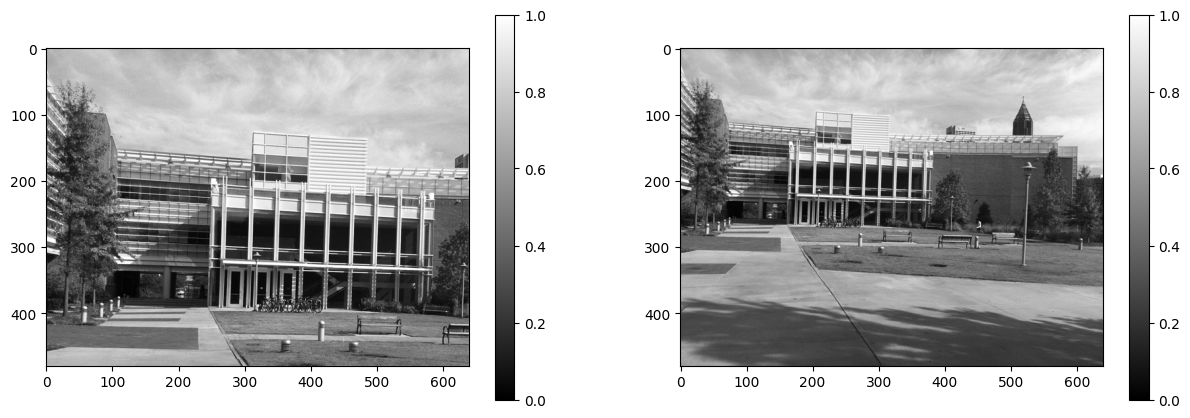

In [233]:
input_dir = Path('input')

img_trans_a = cv.imread(str(input_dir / 'transA.jpg'), cv.IMREAD_UNCHANGED)
img_sim_a = cv.imread(str(input_dir / 'simA.jpg'), cv.IMREAD_UNCHANGED)

img_trans_a = img_trans_a.astype(np.float32) / 255
img_sim_a = img_sim_a.astype(np.float32) / 255

plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.imshow(img_trans_a, cmap="gray")
plt.colorbar()
plt.subplot(122)
plt.imshow(img_sim_a, cmap="gray")
plt.colorbar()
plt.show()

In [234]:
def compute_gradients(img, kernel_size=3, sigma=3):
    img = img.copy().astype(np.float32)
    img = cv.GaussianBlur(img, (kernel_size, kernel_size), sigma)
    sobelx = cv.Sobel(img,cv.CV_64F,1,0,ksize=kernel_size)
    sobely = cv.Sobel(img,cv.CV_64F,0,1,ksize=kernel_size)
    
    return sobelx, sobely

def concat_images(img1, img2):
    return np.hstack([img1, img2])

### Display the "gradient pair" (a concatenation of both images)

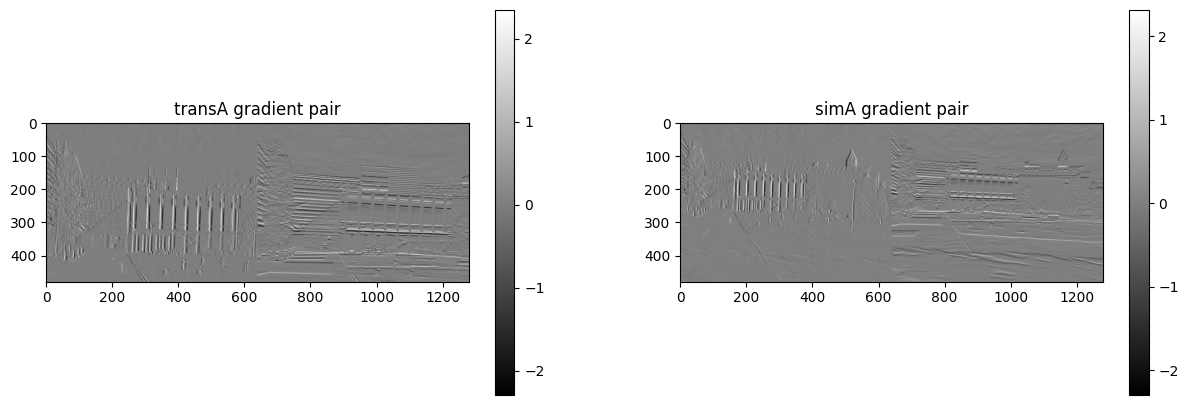

In [235]:


trans_a_sobelx, trans_a_sobely = compute_gradients(img_trans_a, 3, 3)
trans_a_gradient_pair = concat_images(trans_a_sobelx, trans_a_sobely)

sim_a_sobelx, sim_a_sobely = compute_gradients(img_sim_a, 3, 3)
sim_a_gradient_pair = concat_images(sim_a_sobelx, sim_a_sobely)
plt.figure(figsize=(15, 5))
plt.subplot(121)
plt.title("transA gradient pair")
# plt.imshow(trans_a_gradient_pair, cmap='gray', vmin=-1, vmax=1)
plt.imshow(trans_a_gradient_pair, cmap='gray')
plt.colorbar()
plt.subplot(122)
plt.title("simA gradient pair")
plt.imshow(sim_a_gradient_pair, cmap='gray')
plt.colorbar()
plt.show()

## Part B
Now you can compute the Harris value for the image. As a reminder the Harris value was defined as:

$R = \det(M) - \alpha \, \text{trace}(M)^2$

where

$ M = \sum_{x, y} w(x, y) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$

The only design decisions are the size of the window (the sum), the windowing function that controls the weights, and the value of α in the Harris scoring function. Remember you can check you code on the checkerboard images, though those might use a different optimal window size than the real ones.

Write code to compute the Harris value. You can try the weights just equal to 1. But it might work better with a smoother Gaussian that is higher at the middle and falls off gradually. Your output is a scalar function. Apply to transA, transB, simA, and simB.
(To display the output reasonably you will have to scale the image values to be in a range of 0-255 or 0.0 to 1.0, depending upon how you deal with images.)



In [236]:
def find_harris_value(img, alpha=0.05, window_size=(7,7), sigma=5):
    I_x, I_y = compute_gradients(img)
    I_x_I_y = I_x * I_y

    I_x_2 = np.square(I_x)
    I_y_2 = np.square(I_y)
    
    I_x_2 = cv.GaussianBlur(I_x_2, window_size, sigma)
    I_y_2 = cv.GaussianBlur(I_y_2, window_size, sigma)

    I_x_I_y = cv.GaussianBlur(I_x_I_y, window_size, sigma)

    M_det = I_x_2 * I_y_2 - np.square(I_x_I_y)
    M_trace = I_x_2 + I_y_2
    R = M_det - alpha * np.square(M_trace)
    return R


In [237]:
H = find_harris_value(img_trans_a)
print("Max value", H.max())
print("min value", H.min())

Max value 0.5615218909363499
min value -0.299543789766468


## Part C

Finally you can find some corner points. To do this requires two steps: thresholding and non- maximal suppression. You’ll need to choose a threshold value that eliminates points that don’t seem to be plausible corners. And for the non-maximal suppression, you’ll need to choose a radius (could be size of a side of a square window instead of a circle radius) over which a pixel has to be a maximum.

Write a function to threshold and do non-maximal suppression on the Harris output. Surprise, huh? Adjust the threshold and radius until you get a “nice” set of points, probably on the order of a hundred or two (or three?). But use your judgment in terms of getting enough points. Are there any points that are visible in both images but not found as corners in both?


In [255]:
# Apply non maximum supression and thresholding
def find_corner_points(H, threshold=0.01):
    max_filter = ndimage.maximum_filter(H, size=7)
    min_filter = ndimage.minimum_filter(H, size=7)

    mask = (max_filter == H) & (max_filter != min_filter) & (H >= threshold)
    indices = np.argwhere(mask)
    values = [H[index[0],index[1]] for index in indices]
    sorted_indices = np.argsort(values)[::-1]
    peaks = indices[sorted_indices]
    
    return peaks

def view_corners(H, corners, img, radius=1):
    corners_img = np.copy(img)
    corners_img = cv.cvtColor(corners_img, cv.COLOR_GRAY2BGR)

    for pt in corners:
        cv.circle(corners_img, pt[::-1], radius=radius, color=[200,200,0], thickness=2)

    
    plt.figure(figsize=(20,7))
    plt.imshow(corners_img, cmap="gray",)
    plt.colorbar()

    plt.show()

def show_harris_corners(img, alpha=0.05, window_size=7, sigma=5, threshold=0.01):
    H = find_harris_value(img, alpha=alpha, window_size=(window_size, window_size), sigma=sigma)
    corner_points = find_corner_points(H, threshold)
    view_corners(H, corner_points, img)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..200.0].


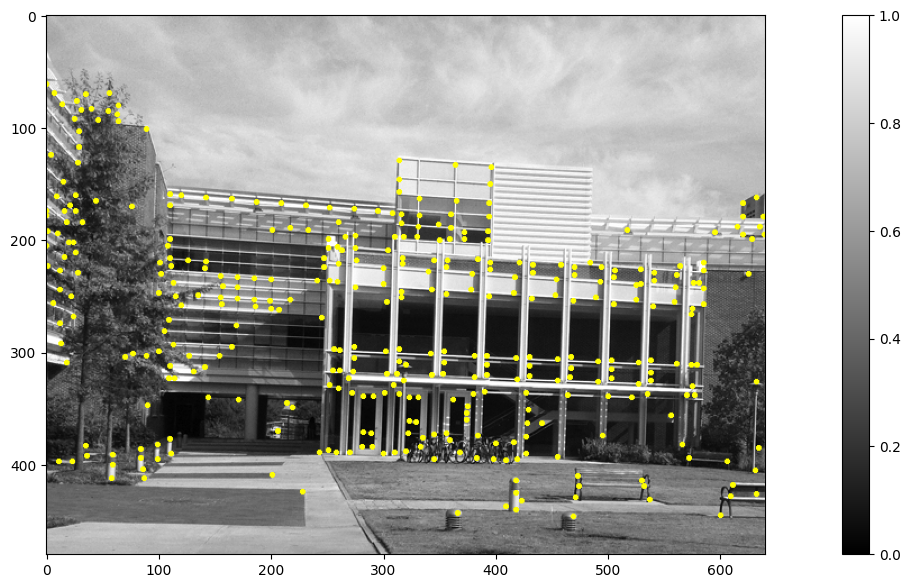

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..200.0].


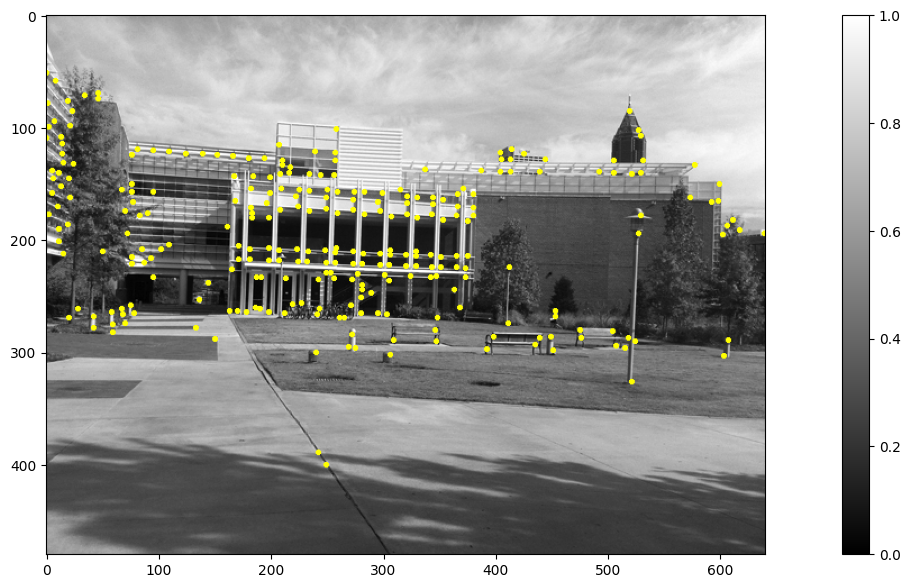

In [256]:
show_harris_corners(img_trans_a, threshold=0.01)
show_harris_corners(img_sim_a)
